In [111]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from interpret.glassbox import ExplainableBoostingRegressor

In [112]:
path = r"C:\Users\Aaron\OneDrive\Desktop\Capstone\Data\Features"

precipitation = pd.read_csv(path + "\Weather\Precipitation1985_2025.csv")
sunshineDuration = pd.read_csv(path + "\Weather\SunshineDuration1985_2025.csv")
airTemperature = pd.read_csv(path + "\Weather\AirTemperature1985_2025.csv")

In [113]:
season_map = {
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn',
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
}

roll_forward = ['September', 'October', 'November', 'December']

In [114]:
def season_weather(monthly_average, colname):
    df = monthly_average.copy()
    df['Season'] = df['Month'].map(season_map)

    rollOn_month = df['Month'].isin(roll_forward)
    df['HarvestYear'] = np.where(rollOn_month, df['Year'] + 1, df['Year'])

    season_avg = df.groupby(['HarvestYear', 'Season'])['Measurement'].mean().reset_index()

    pivot = season_avg.pivot(index='HarvestYear', columns='Season', values='Measurement')
    pivot.columns = [f'{colname}_{s}' for s in pivot.columns]

    return pivot.reset_index().rename(columns={'HarvestYear': 'Year'})

In [115]:
def build_features():
    return (season_weather(precipitation, 'Precip')
            .merge(season_weather(sunshineDuration, 'Sun'), on='Year')
            .merge(season_weather(airTemperature, 'TempMean'), on='Year'))


features = build_features()

In [116]:
def detrend_yield(yield_data):
    yield_copy = yield_data.copy()

    slope, intercept = np.polyfit(yield_copy['Year'], yield_copy['Tonnes'], deg=1)
    yield_copy['Trend'] = slope * yield_copy['Year'] + intercept
    yield_copy['Yield_Detrended'] = yield_copy['Tonnes'] - yield_copy['Trend']

    return yield_copy

In [117]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

In [118]:
def run_ebm(X, y, params):
    y_true = []
    y_pred = []
 
    for train_index, test_index in loo.split(X):
        model = ExplainableBoostingRegressor(random_state=42, n_jobs=1, **params)
        model.fit(X.iloc[train_index], y.iloc[train_index])
 
        y_pred.append(model.predict(X.iloc[test_index])[0])
        y_true.append(y.iloc[test_index].values[0])
 
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
 
    return rmse, mae, r2

In [ ]:
import itertools

def best_hyperparameters_ebm(X, y):
    
    hyperparameter_grid = {
        'outer_bags': [4, 5],
        'learning_rate': [0.01, 0.02, 0.03],
        'min_samples_leaf': [2, 3],
        'interactions': [0, 3],   
    }
 
    parameter_names = list(hyperparameter_grid.keys())
    parameter_value_lists = list(hyperparameter_grid.values())
 
    best_result = {'r2': -np.inf}
 
    for combination in itertools.product(*parameter_value_lists):
        params = dict(zip(parameter_names, combination))
        rmse, mae, r2 = run_ebm(X, y, params)
 
        if r2 > best_result['r2']:
            best_result = {'params': params, 'rmse': rmse, 'mae': mae, 'r2': r2}
 
    print(f"Best hyperparamters: {best_result['params']} R2={best_result['r2']:.3f}")
    return best_result['params']

In [120]:
def permutation_test_ebm(X, y, params, shuffles=250):
    rng = np.random.default_rng(1)
 
    _, _, r2 = run_ebm(X, y, params)
 
    permuted_r2 = []
 
    for i in range(shuffles):
        shuffled_y = pd.Series(rng.permutation(y.values), index=y.index)
        _, _, perm_r2 = run_ebm(X, shuffled_y, params)
        permuted_r2.append(perm_r2)
 
    permuted_r2 = np.array(permuted_r2)
 
    good_permutations = np.sum(permuted_r2 >= r2)
    p_value = (good_permutations + 1) / (shuffles + 1)
 
    return p_value

In [121]:
crop_paths = [
    (path + r"\CropYield\SpringWheat1985_2025.csv", 'SpringWheat'),
    (path + r"\CropYield\WinterWheat1985_2025.csv", 'WinterWheat'),
    (path + r"\CropYield\SpringBarley1985_2025.csv", 'SpringBarley'),
    (path + r"\CropYield\WinterBarley1985_2025.csv", 'WinterBarley'),
    (path + r"\CropYield\SpringOats1985_2025.csv", 'SpringOats'),
    (path + r"\CropYield\WinterOats1985_2025.csv", 'WinterOats'),
    (path + r"\CropYield\Potatoes1985_2025.csv", 'Potatoes'),
    (path + r"\CropYield\OilseedRape1985_2025.csv", 'OilseedRape'),
    (path + r"\CropYield\BeansAndPeas1985_2025.csv", 'BeansAndPeas'),
]
 
reference_yield = detrend_yield(pd.read_csv(crop_paths[0][0])[['Year', 'Tonnes']])
reference_data = features.merge(reference_yield, on='Year').dropna().sort_values('Year').reset_index(drop=True)

X_reference = reference_data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
y_reference = reference_data['Yield_Detrended']
 
params_ebm = best_hyperparameters_ebm(X_reference, y_reference)

Best hyperparamters: {'outer_bags': 4, 'learning_rate': 0.01, 'min_samples_leaf': 2, 'interactions': 3} -> R2=0.146


In [122]:
for csv, crop in crop_paths:
 
    yield_df = detrend_yield(pd.read_csv(csv)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    rmse, mae, r2 = run_ebm(X, y, params_ebm)
    
    if crop in ['SpringWheat', 'SpringBarley', 'SpringOats', 'Potatoes']:
        
        p_value = permutation_test_ebm(X, y, params_ebm)

        print(f"{crop:15s} RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}  p={p_value:.4f}")

    else:
        print(f"{crop:15s} RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}")

SpringWheat     RMSE=0.617  MAE=0.500  R2=0.146  p=0.0199
WinterWheat     RMSE=0.895  MAE=0.739  R2=-0.033
SpringBarley    RMSE=0.520  MAE=0.412  R2=0.201  p=0.0080
WinterBarley    RMSE=0.695  MAE=0.528  R2=-0.079
SpringOats      RMSE=0.423  MAE=0.325  R2=0.264  p=0.0040
WinterOats      RMSE=0.469  MAE=0.369  R2=-0.044
Potatoes        RMSE=3.490  MAE=2.806  R2=0.139  p=0.0199
OilseedRape     RMSE=0.896  MAE=0.699  R2=-0.312
BeansAndPeas    RMSE=1.479  MAE=1.186  R2=-0.303



SpringWheat Feature importance:
Sun_Summer                 0.0720
Precip_Summer              0.0688
Sun_Autumn                 0.0678
TempMean_Summer            0.0602
Sun_Autumn & Sun_Summer    0.0524
TempMean_Winter            0.0511
Precip_Summer & TempMean_Spring  0.0429
Precip_Autumn              0.0363
TempMean_Autumn            0.0362
Precip_Spring              0.0360
Precip_Winter              0.0326
Sun_Spring & TempMean_Winter  0.0292
Sun_Spring                 0.0271
TempMean_Spring            0.0209
Sun_Winter                 0.0117


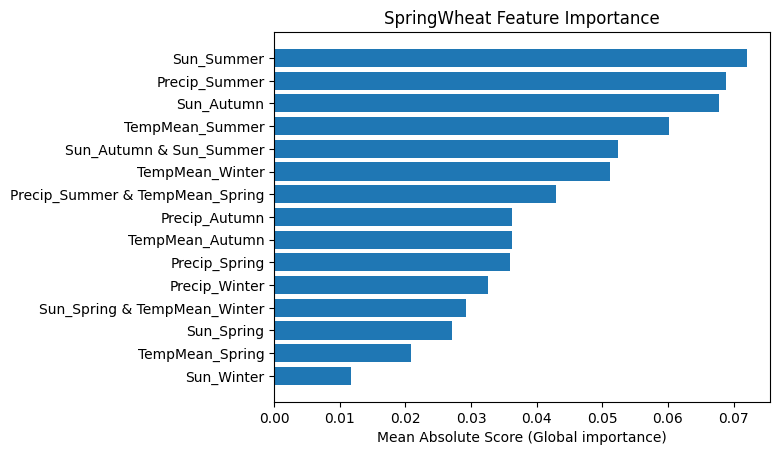


SpringBarley Feature importance:
Sun_Autumn                 0.1168
Precip_Summer              0.1089
Precip_Spring              0.1070
TempMean_Summer            0.0802
Sun_Summer                 0.0762
Sun_Spring                 0.0749
Sun_Winter                 0.0639
TempMean_Winter            0.0574
TempMean_Spring            0.0465
Precip_Autumn              0.0439
Precip_Spring & Sun_Autumn  0.0415
Precip_Summer & TempMean_Autumn  0.0344
TempMean_Autumn            0.0279
Precip_Winter              0.0263
Sun_Spring & Sun_Winter    0.0157


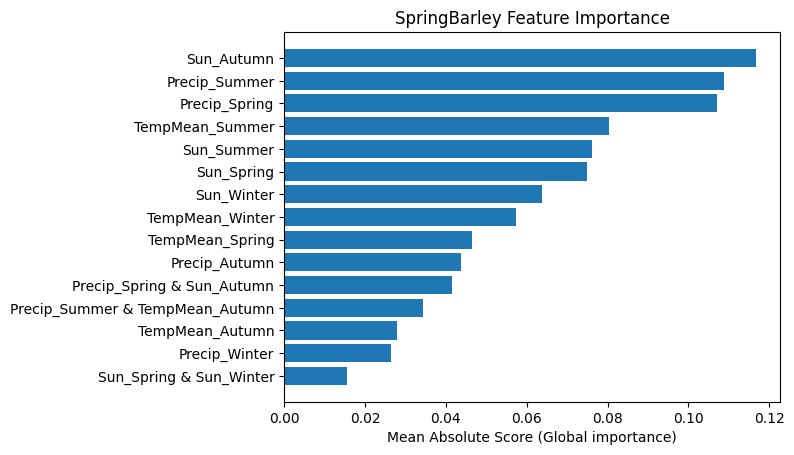


SpringOats Feature importance:
Precip_Summer              0.0960
Sun_Autumn                 0.0759
TempMean_Summer            0.0753
Precip_Spring              0.0597
Sun_Summer                 0.0533
Sun_Spring                 0.0386
Precip_Spring & Sun_Autumn  0.0300
Precip_Summer & TempMean_Autumn  0.0291
TempMean_Winter            0.0275
Sun_Winter                 0.0273
TempMean_Spring            0.0217
Precip_Winter & Sun_Winter  0.0208
TempMean_Autumn            0.0197
Precip_Winter              0.0169
Precip_Autumn              0.0133


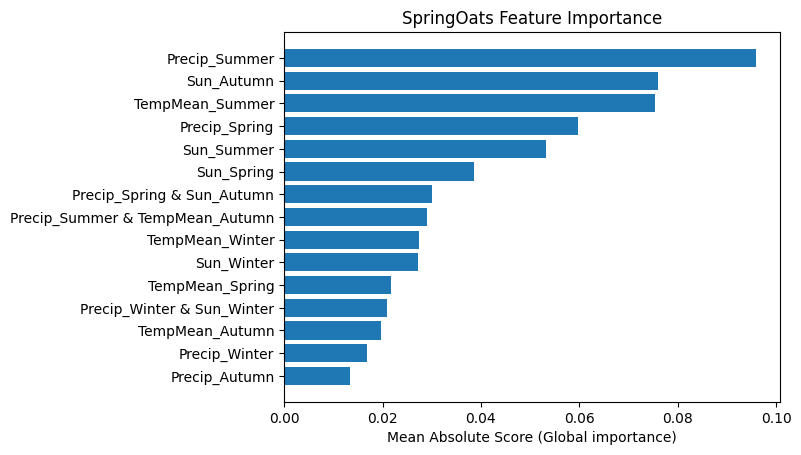


Potatoes Feature importance:
Precip_Summer              0.5050
Precip_Autumn              0.4713
Sun_Autumn                 0.4023
Sun_Summer                 0.3617
Precip_Summer & Sun_Autumn  0.3444
Precip_Summer & Sun_Summer  0.3313
TempMean_Winter            0.2583
Precip_Summer & TempMean_Spring  0.2100
TempMean_Autumn            0.1615
TempMean_Summer            0.1521
Sun_Spring                 0.1119
Precip_Winter              0.0969
TempMean_Spring            0.0846
Precip_Spring              0.0812
Sun_Winter                 0.0529


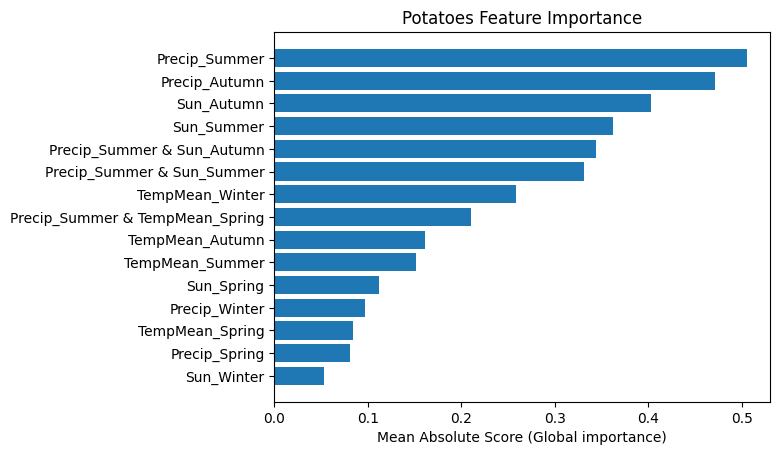

In [134]:
from interpret.glassbox import ExplainableBoostingRegressor
import matplotlib.pyplot as plt
 
significant_crops = [
    (path + r"\CropYield\SpringWheat1985_2025.csv", 'SpringWheat'),
    (path + r"\CropYield\SpringBarley1985_2025.csv", 'SpringBarley'),
    (path + r"\CropYield\SpringOats1985_2025.csv", 'SpringOats'),
    (path + r"\CropYield\Potatoes1985_2025.csv", 'Potatoes'),
]
 
ebm_models = {}  
 
for csv_path, crop_name in significant_crops:
 
    yield_df = detrend_yield(pd.read_csv(csv_path)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    model = ExplainableBoostingRegressor(random_state=42, n_jobs=1, **params_ebm)
    model.fit(X, y)
    ebm_models[crop_name] = model
 
    explanation_data = model.explain_global().data()
    sorted_pairs = sorted(zip(explanation_data['names'], explanation_data['scores']), key=lambda pair: pair[1], reverse=True)
    sorted_names, sorted_scores = zip(*sorted_pairs)
 
    print(f"\n{crop_name} Feature importance:")
    for name, score in zip(sorted_names, sorted_scores):
        print(f"{name:25s}  {score:.4f}")
 
    plt.barh(sorted_names[::-1], sorted_scores[::-1])
    plt.xlabel('Mean Absolute Score (Global importance)')
    plt.title(f'{crop_name} Feature Importance')
    plt.show()

In [136]:
for crop_name, model in ebm_models.items():

    ebm_global = model.explain_global()

    print(f"\n{crop_name}")
 
    global_data = ebm_global.data()
    sorted_pairs = sorted(zip(global_data['names'], global_data['scores']), key=lambda pair: pair[1], reverse=True)
 
    top_features = [name for name, score in sorted_pairs if '&' not in name][:5]
 
    for feature_name in top_features:
        term_index = list(model.term_names_).index(feature_name)
        term_data = ebm_global.data(term_index)
 
        low_score = term_data['scores'][0]
        high_score = term_data['scores'][-1]
        direction = "Positive" if high_score > low_score else "Negative"
 
        print(f"{feature_name:20s} low={low_score:.3f}  high={high_score:.3f}: {direction}")


SpringWheat
Sun_Summer           low=-0.217  high=0.088: Positive
Precip_Summer        low=0.004  high=-0.278: Negative
Sun_Autumn           low=-0.133  high=0.162: Positive
TempMean_Summer      low=0.085  high=-0.231: Negative
TempMean_Winter      low=-0.138  high=0.042: Positive

SpringBarley
Sun_Autumn           low=-0.261  high=0.200: Positive
Precip_Summer        low=0.062  high=-0.332: Negative
Precip_Spring        low=0.062  high=-0.280: Negative
TempMean_Summer      low=0.167  high=-0.269: Negative
Sun_Summer           low=-0.211  high=0.023: Positive

SpringOats
Precip_Summer        low=0.009  high=-0.286: Negative
Sun_Autumn           low=-0.106  high=0.070: Positive
TempMean_Summer      low=0.217  high=-0.199: Negative
Precip_Spring        low=0.015  high=-0.219: Negative
Sun_Summer           low=-0.165  high=0.067: Positive

Potatoes
Precip_Summer        low=-0.083  high=-1.850: Negative
Precip_Autumn        low=0.384  high=-0.935: Negative
Sun_Autumn           low=-1.238 

In [137]:
winter_crops = [
    (path + r"\CropYield\WinterWheat1985_2025.csv", 'WinterWheat'),
    (path + r"\CropYield\WinterBarley1985_2025.csv", 'WinterBarley'),
    (path + r"\CropYield\WinterOats1985_2025.csv", 'WinterOats'),
]
  
for csv_path, crop_name in winter_crops:
    yield_df = detrend_yield(pd.read_csv(csv_path)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    print(f"\n{crop_name}")
    crop_params = best_hyperparameters_ebm(X, y)
 
    rmse, mae, r2 = run_ebm(X, y, crop_params)
    print(f"{crop_name:15s} RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}")
 


WinterWheat
Best hyperparamters: {'outer_bags': 4, 'learning_rate': 0.01, 'min_samples_leaf': 2, 'interactions': 3} -> R2=-0.033
WinterWheat     RMSE=0.895  MAE=0.739  R2=-0.033

WinterBarley
Best hyperparamters: {'outer_bags': 4, 'learning_rate': 0.01, 'min_samples_leaf': 3, 'interactions': 3} -> R2=0.018
WinterBarley    RMSE=0.663  MAE=0.513  R2=0.018

WinterOats
Best hyperparamters: {'outer_bags': 4, 'learning_rate': 0.01, 'min_samples_leaf': 3, 'interactions': 3} -> R2=-0.041
WinterOats      RMSE=0.469  MAE=0.372  R2=-0.041
